In [1]:
from keras import models

2026-09-25 22:55:23.810273: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1790355323.827570  120718 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1790355323.834514  120718 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1790355323.849674  120718 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1790355323.849709  120718 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1790355323.849712  120718 computation_placer.cc:177] computation placer alr

In [3]:
best_accuracy_model = models.load_model('models_experiment_7(best)/weights.51-0.9977.keras')

I0000 00:00:1790355345.738431  120718 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9436 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:05:00.0, compute capability: 8.6


In [ ]:
best_loss_model = models.load_model('models_experiment_7(best)/weights.66-0.9972.keras')

In [ ]:
from keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train/255.0
x_test = x_test/255.0

In [ ]:
best_accuracy_model.evaluate(x_test, y_test)

2026-09-16 00:46:42.246708: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91801


313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - loss: 0.0081 - sparse_categorical_accuracy: 0.9977


[0.008142831735312939, 0.9976999759674072]

In [ ]:
best_loss_model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0081 - sparse_categorical_accuracy: 0.9972


[0.008101027458906174, 0.9972000122070312]

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image


def preprocess_digit(image_path, invert=False):
    image = Image.open(image_path).convert("L")

    if invert:
        image = Image.eval(image, lambda pixel: 255 - pixel)

    image = image.resize((28, 28))

    image_array = np.array(image).astype("float32") / 255.0

    image_array = image_array.reshape(1, 28, 28, 1)

    return image_array


image_array = preprocess_digit(
    "2.png",
    invert=False
)

In [ ]:
image_array

array([[[[0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824]],

        [[0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         [0.07058824],
         

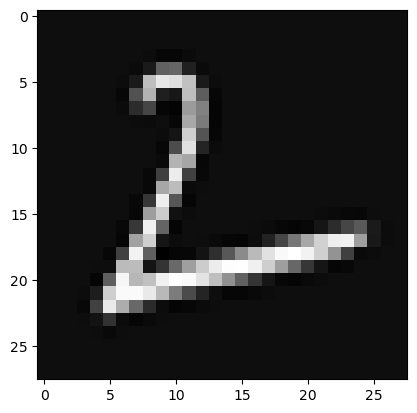

In [ ]:
plt.imshow(image_array[0], cmap='gray')

In [ ]:
import numpy as np

prob_vector = best_accuracy_model.predict(image_array)

for i in range(len(prob_vector[0])):
    print(f'probability of class {i} is {prob_vector[0][i]*100:.2f}%')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 900ms/step
probability of class 0 is 0.12%
probability of class 1 is 0.00%
probability of class 2 is 42.30%
probability of class 3 is 0.01%
probability of class 4 is 0.17%
probability of class 5 is 0.00%
probability of class 6 is 0.01%
probability of class 7 is 0.00%
probability of class 8 is 57.31%
probability of class 9 is 0.09%


In [11]:
import numpy as np

prob_vector = best_loss_model.predict(image_array)

for i in range(len(prob_vector[0])):
    print(f'probability of class {i} is {prob_vector[0][i]*100:.2f}%')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
probability of class 0 is 0.01%
probability of class 1 is 0.00%
probability of class 2 is 99.88%
probability of class 3 is 0.00%
probability of class 4 is 0.00%
probability of class 5 is 0.00%
probability of class 6 is 0.00%
probability of class 7 is 0.00%
probability of class 8 is 0.11%
probability of class 9 is 0.00%
